In [9]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [10]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------
custom_map = [
    "FFSF",
    "FHFH",
    "FFFH",
    "HGFF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=False
)

In [11]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------
num_episodes = 8000
max_steps = 100

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995


In [12]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros(
    (
        env.observation_space.n,
        env.action_space.n
    )
)

print("Q-table shape:", Q.shape)
# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    else:
        return np.argmax(Q[state])

Q-table shape: (16, 4)


In [13]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):
        action = epsilon_greedy_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        best_next_action_value = np.max(Q[next_state])
        Q[state, action] = Q[state, action] + alpha * (
            reward
            + gamma * best_next_action_value
            - Q[state, action]
        )
        state = next_state
        total_reward += reward

        if terminated or truncated:
            break
    episode_rewards.append(total_reward)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

        if epsilon < epsilon_min:
            epsilon = epsilon_min

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)



In [14]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [15]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.    0.    0.15  0.   ]
 [0.008 0.    0.961 0.222]
 [0.951 0.97  0.951 0.961]
 [0.961 0.    0.057 0.148]
 [0.    0.001 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.961]
 [0.    0.    0.    0.   ]
 [0.    0.    0.303 0.   ]
 [0.041 1.    0.33  0.   ]
 [0.99  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [1.    0.99  0.98  0.98 ]
 [0.99  0.253 0.23  0.   ]]

Estimated State-Value Function:
[[0.15  0.961 0.97  0.961]
 [0.001 0.    0.98  0.   ]
 [0.303 1.    0.99  0.   ]
 [0.    0.    1.    0.99 ]]

Learned Policy:
[['R' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'D' 'D' 'L']
 ['L' 'L' 'L' 'L']]

Average reward over last 1000 episodes: 0.964


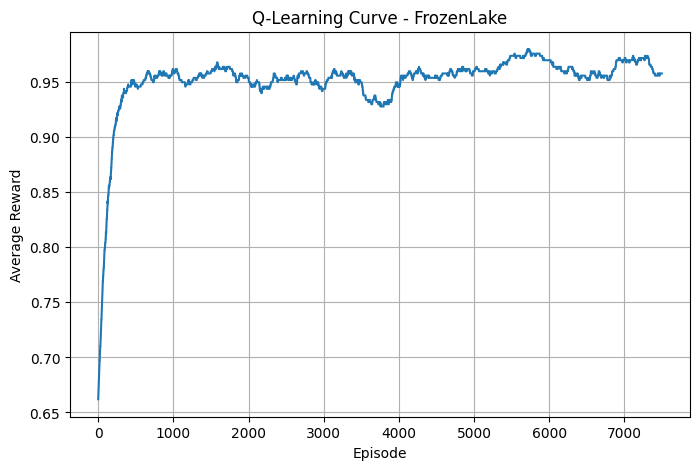

In [16]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()